In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [69]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.shape
# df_clean.hist(figsize=(20,20))
# print(df_clean.isnull().sum())

(3167, 13)

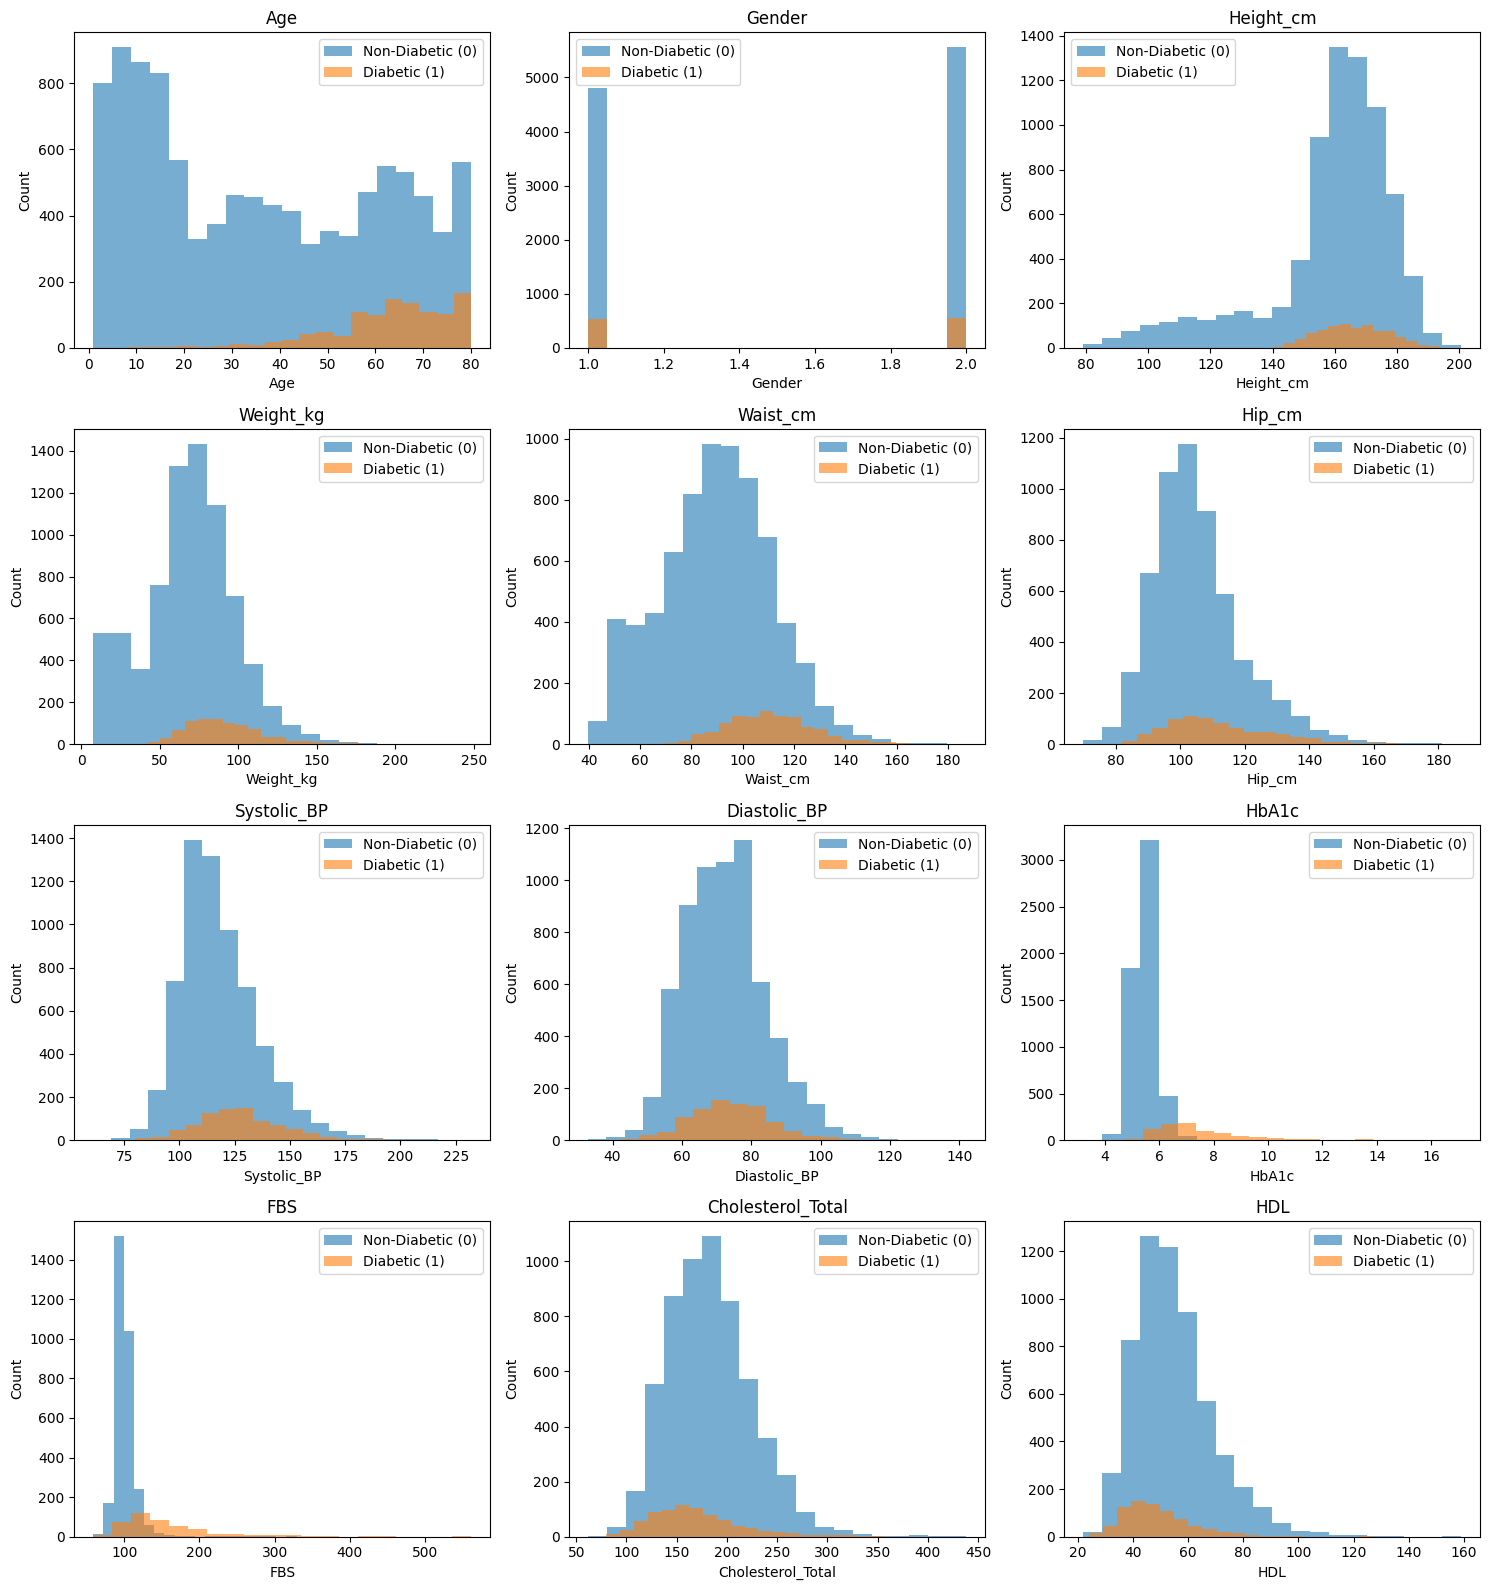

In [ ]:
import matplotlib.pyplot as plt

target = "Diabetes_Status"
features = df_clean.drop(columns=[target]).columns

# create grid: adjust rows/cols depending on number of features
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # auto rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # make axes iterable

for i, col in enumerate(features):
    ax = axes[i]
    df[df[target] == 0][col].plot(kind="hist", bins=20, alpha=0.6, label="Non-Diabetic (0)", ax=ax)
    df[df[target] == 1][col].plot(kind="hist", bins=20, alpha=0.6, label="Diabetic (1)", ax=ax)

    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("diabetes_distributions.png", dpi=300)  # save image
plt.show()


<Axes: >

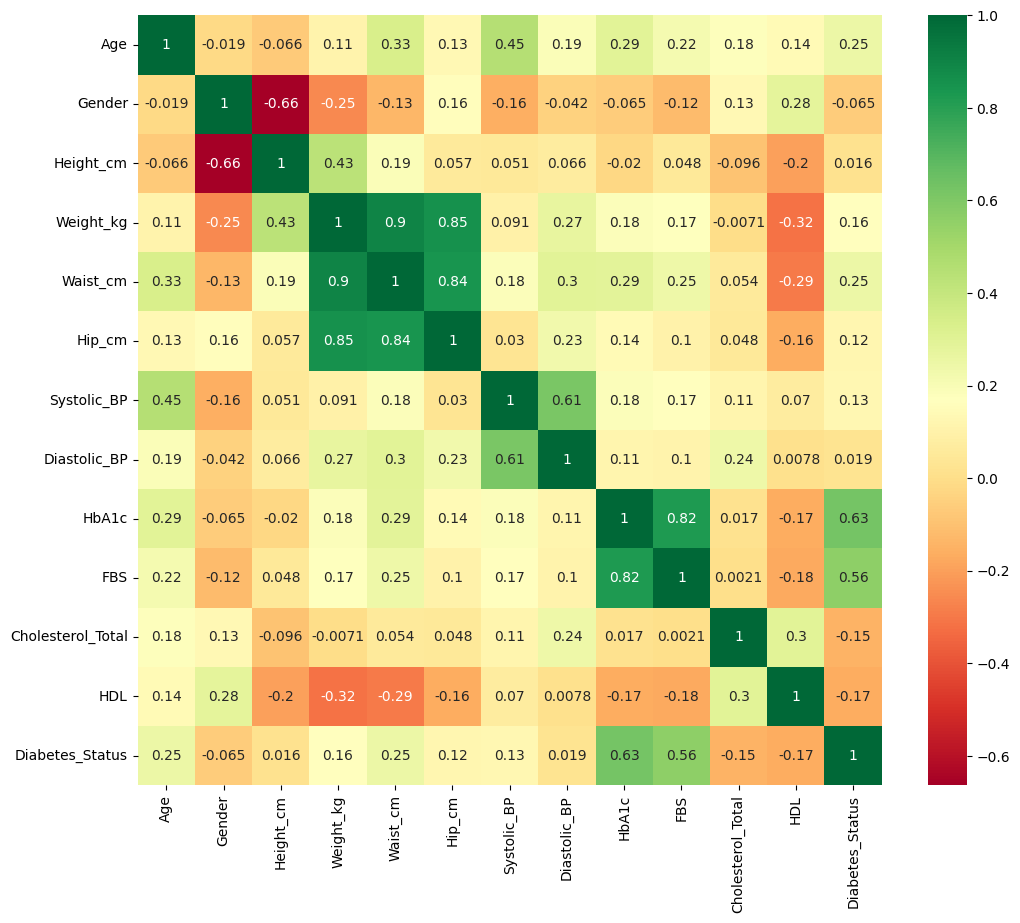

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn')

In [70]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Diabetes_Status"])
y = df_clean["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train ratio:\n", X_train.value_counts(normalize=True))
print("Valid ratio:\n", X_test.value_counts(normalize=True))


Train ratio:
 Age   Gender  Height_cm  Weight_kg  Waist_cm  Hip_cm  Systolic_BP  Diastolic_BP  HbA1c  FBS    Cholesterol_Total  HDL 
80.0  2.0     171.7      75.1       89.5      110.2   155.0        55.0          5.7    92.0   201.0              63.0    0.000395
12.0  1.0     136.7      39.0       69.5      77.6    96.0         70.0          5.2    105.0  126.0              43.0    0.000395
              148.6      46.7       72.2      72.2    113.0        68.0          5.0    100.0  174.0              35.0    0.000395
              148.8      53.1       86.4      89.1    111.0        73.0          5.0    104.0  216.0              50.0    0.000395
              152.7      62.4       90.5      97.5    94.0         62.0          5.2    96.0   184.0              51.0    0.000395
                                                                                                                            ...   
              161.2      54.7       76.5      87.9    106.0        47.0          

In [ ]:
train = pd.DataFrame(X_train, columns=X.columns)
train["Diabetes_Status"] = y_train

valid = pd.DataFrame(X_valid, columns=X.columns)
valid["Diabetes_Status"] = y_valid

test = pd.DataFrame(X_test, columns=X.columns)
test["Diabetes_Status"] = y_test

In [ ]:
train['Diabetes_Status'].value_counts()
valid['Diabetes_Status'].value_counts()
test['Diabetes_Status'].value_counts()


,count
Diabetes_Status,
0.0,557
1.0,77


# **Raw Dataset Training**
all values are raw that contains NaN.

GENDER:
*   MALE: 1,
*   FEMALE: 2

DIABETES STATS:
*   YES: 1
*   NO: 0





# Feature Importance

Gini Importance

              Feature  Gini Importance
8               HbA1c         0.388754
9                 FBS         0.194397
0                 Age         0.094310
4            Waist_cm         0.057564
10  Cholesterol_Total         0.053299
11                HDL         0.041388
2           Height_cm         0.038546
3           Weight_kg         0.037479
6         Systolic_BP         0.032718
5              Hip_cm         0.030412
7        Diastolic_BP         0.026376
1              Gender         0.004757


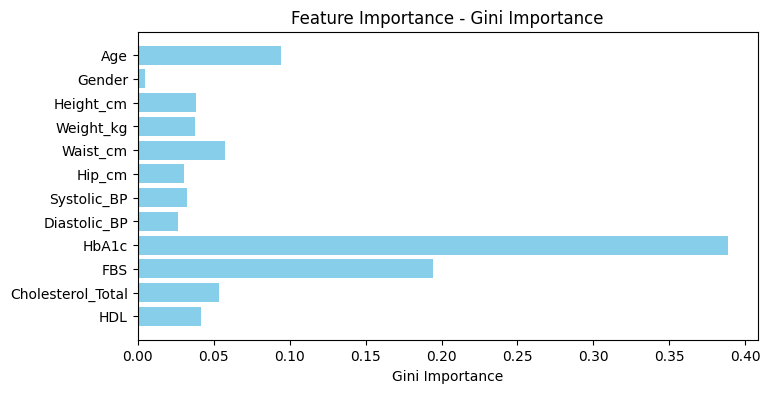

In [ ]:
import shap
feature_names = df_clean.columns[:-1]
importances = forest_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

# TRAINING

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [72]:
numeric_features = X_train.columns.tolist()

over = SMOTE()
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

preprocessor_SMOTE = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)
print(numeric_features)

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm', 'Systolic_BP', 'Diastolic_BP', 'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']


In [77]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


🔹 Training Logistic Regression...
ROC-AUC: 0.9782
F1-Score: 0.7236
              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95       558
         1.0       0.59      0.95      0.72        76

    accuracy                           0.91       634
   macro avg       0.79      0.93      0.84       634
weighted avg       0.94      0.91      0.92       634



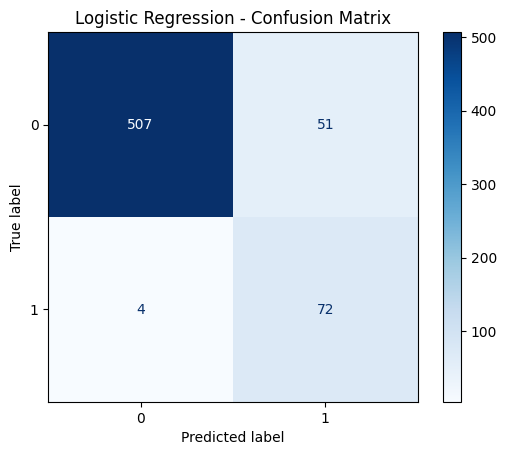


🔹 Training Random Forest...
ROC-AUC: 0.9670
F1-Score: 0.7219
              precision    recall  f1-score   support

         0.0       0.97      0.94      0.96       558
         1.0       0.66      0.80      0.72        76

    accuracy                           0.93       634
   macro avg       0.81      0.87      0.84       634
weighted avg       0.93      0.93      0.93       634



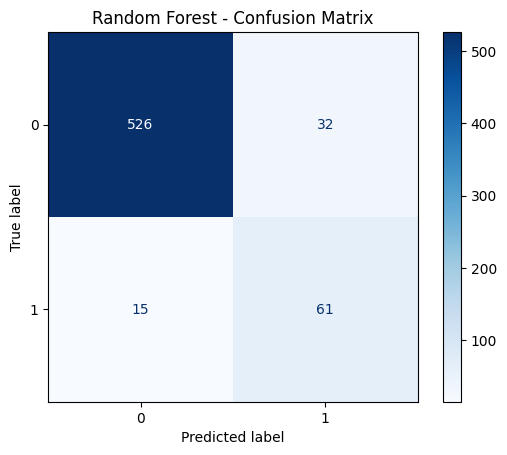


🔹 Training KNN...
ROC-AUC: 0.9100
F1-Score: 0.6471
              precision    recall  f1-score   support

         0.0       0.98      0.89      0.93       558
         1.0       0.52      0.87      0.65        76

    accuracy                           0.89       634
   macro avg       0.75      0.88      0.79       634
weighted avg       0.92      0.89      0.90       634



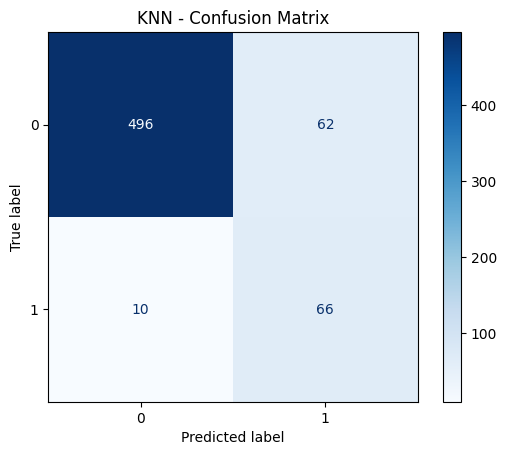


🔹 Training Naive Bayes...
ROC-AUC: 0.9643
F1-Score: 0.7135
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       558
         1.0       0.61      0.87      0.71        76

    accuracy                           0.92       634
   macro avg       0.79      0.90      0.83       634
weighted avg       0.94      0.92      0.92       634



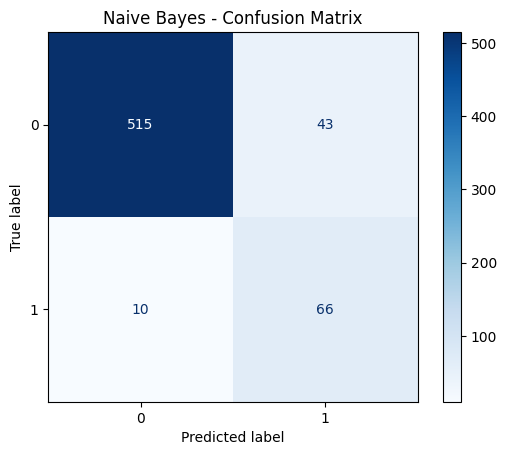


🔹 Training SVM...
ROC-AUC: 0.9703
F1-Score: 0.7053
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       558
         1.0       0.59      0.88      0.71        76

    accuracy                           0.91       634
   macro avg       0.79      0.90      0.83       634
weighted avg       0.94      0.91      0.92       634



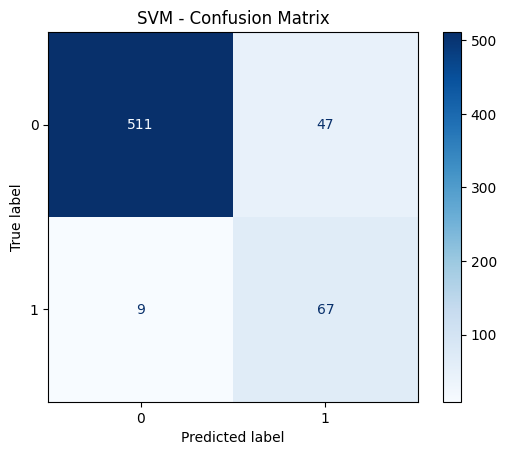


🔹 Training XGBoost...
ROC-AUC: 0.9625
F1-Score: 0.7261
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96       558
         1.0       0.70      0.75      0.73        76

    accuracy                           0.93       634
   macro avg       0.83      0.85      0.84       634
weighted avg       0.93      0.93      0.93       634



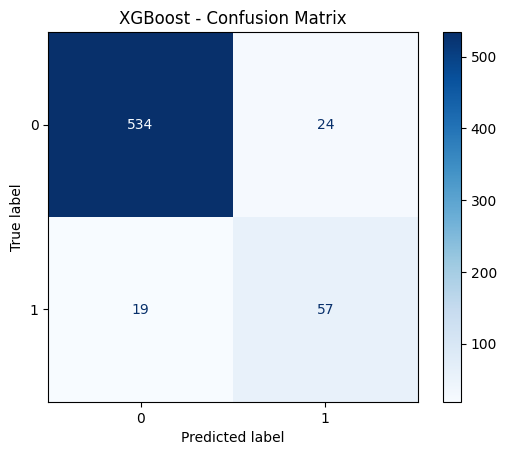


🏆 BEST MODEL: Logistic Regression with ROC-AUC: 0.9782


In [78]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('over', over),
              ('under', under),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor),
              ('over', over),
              ('under', under),
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        y_proba = pipe.predict_proba(X_valid)[:, 1]

        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results

# Usage
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


🔹 Training Logistic Regression 2...
ROC-AUC: 0.9787
F1-Score: 0.7200
              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95       558
         1.0       0.58      0.95      0.72        76

    accuracy                           0.91       634
   macro avg       0.79      0.93      0.83       634
weighted avg       0.94      0.91      0.92       634



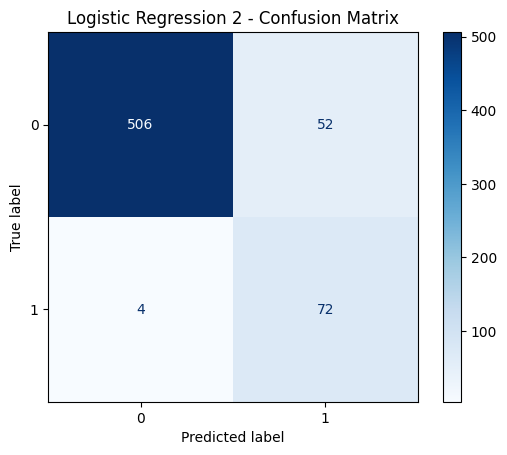

{'Logistic Regression 2': {'model': Pipeline(steps=[('preprocess',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('num', StandardScaler(),
                                                    ['Age', 'Gender', 'Height_cm',
                                                     'Weight_kg', 'Waist_cm',
                                                     'Hip_cm', 'Systolic_BP',
                                                     'Diastolic_BP', 'HbA1c',
                                                     'FBS', 'Cholesterol_Total',
                                                     'HDL'])])),
                  ('over', SMOTE()), ('under', RandomUnderSampler()),
                  ('model',
                   LogisticRegression(C=0.1, class_weight='balanced',
                                      max_iter=1000, random_state=42))]),
  'roc_auc': np.float64(0.9786596868515375),
  'accuracy': 0.9116719242902208,
  'precisi

In [61]:
models_lg = {
    "Logistic Regression 2": LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'),
}

train_and_evaluate_model_SMOTE(models_lg, X_train, y_train, X_test, y_test)


In [26]:


param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best ROC-AUC: 0.9450001170058757


In [33]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Gender', 'Height_cm',
                                                   'Weight_kg', 'Waist_cm',
                                                   'Hip_cm', 'Systolic_BP',
                                                   'Diastolic_BP', 'HbA1c',
                                                   'FBS', 'Cholesterol_Total',
                                                   'HDL'])])),
                ('over', SMOTE()), ('under', RandomUnderSampler()),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [34]:
new_patient = pd.DataFrame([{
    'Age': 85,
    'Gender': 1,
    'Height_cm': 179.5,
    'Weight_kg': 86.9,
    'Waist_cm': 98.3,
    'Hip_cm': 102.9,
    'Systolic_BP': 135,
    'Diastolic_BP': 98,
    'HbA1c': 5.6,
    'FBS': 113,
    'Cholesterol_Total': 264,
    'HDL': 45
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")




Predicted Probability of No Diabetes: 81.10%
Predicted Probability of Diabetes: 18.90%



🔹 Training Random Forest...
0.9676603987527166
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       557
         1.0       0.77      0.80      0.79        76

    accuracy                           0.95       633
   macro avg       0.87      0.89      0.88       633
weighted avg       0.95      0.95      0.95       633



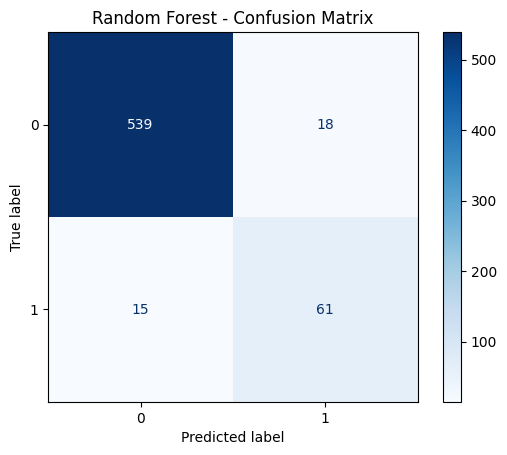

In [20]:
models_RF = {
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42)
  }

train_and_evaluate_model(models_RF, X_train, y_train, X_valid, y_valid)

In [23]:
pipe = ImbPipeline([
    ('oversample', RandomOverSampler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Define parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 20]
}

# Grid search (oversampling occurs correctly inside each fold)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# ✅ Fit on the *original* imbalanced data
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'model__max_depth': 20, 'model__n_estimators': 300}
Best ROC-AUC: 0.9501132155507097
